In [1]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import torch.nn.functional as F
from tqdm import tqdm
# set once — new tensors land on MPS without device= every call
if torch.backends.mps.is_available():
    torch.set_default_device("cpu")
torch.set_printoptions(sci_mode=False)


In [2]:
words = lambda: open("names.txt", 'r').read().splitlines()

In [3]:
stoi = {s:i+1 for i, s in enumerate(sorted(set(''.join(words()))))} | {'.':0,}
itos = {i:s for s, i in stoi.items()}
vocab_size = len(stoi)
block_size = 4


In [4]:
import random

def build_dataset(word_list):
    X, Y = [], []
    for word in word_list:
        context = [0]*block_size
        for w in word+'.':
            idx = stoi[w]
            X.append(context)
            Y.append(idx)
            context = context[1:] + [idx]
    return torch.tensor(X), torch.tensor(Y)

all_words = words()
random.seed(42)
random.shuffle(all_words)

n1 = int(0.8*len(all_words))
n2 = int(0.9*len(all_words))

Xtr, Ytr = build_dataset(all_words[:n1])      # 80% train
Xdev, Ydev = build_dataset(all_words[n1:n2])  # 10% dev
Xte, Yte = build_dataset(all_words[n2:])      # 10% test

print("train:", Xtr.shape[0], " dev:", Xdev.shape[0], " test:", Xte.shape[0])


train: 182625  dev: 22655  test: 22866


In [5]:
embed_dim = 10
hidden_size = 1000
n_embed_total = block_size * embed_dim  # flattened size of block_size embedded characters

C = torch.randn((vocab_size, embed_dim)) * 0.01
W1 = torch.randn(n_embed_total, hidden_size) * 0.01
# no b1: BatchNorm re-centers hpreact anyway, so an additive bias here would
# just get normalized away.
W2 = torch.randn(hidden_size, vocab_size) * 0.01
b2 = torch.randn(vocab_size) * 0.01

# BatchNorm's own learnable scale/shift, applied after normalizing hpreact.
bngain = torch.ones((1, hidden_size))
bnbias = torch.zeros((1, hidden_size))

# Running (population) mean/std, updated via momentum during training, used
# in place of batch statistics at eval time. Not trainable parameters.
bnmean_running = torch.zeros((1, hidden_size))
bnstd_running = torch.ones((1, hidden_size))


In [6]:
parameters = [C, W1, W2, b2, bngain, bnbias]
print(sum((p.nelement() for p in parameters)))


69297


In [7]:
for p in parameters:
    p.requires_grad = True

In [8]:
g = torch.Generator().manual_seed(2147483647)

for _ in tqdm(range(500_000)):
    ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)

    hpreact = C[Xtr[ix]].view(-1, n_embed_total) @ W1
    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi + bnbias
    with torch.no_grad():
        bnmean_running.mul_(0.999).add_(0.001 * bnmeani)
        bnstd_running.mul_(0.999).add_(0.001 * bnstdi)

    h1 = torch.tanh(hpreact)
    logits = h1@W2+b2
    loss = F.cross_entropy(logits, Ytr[ix])

    for p in parameters:
        p.grad = None

    loss.backward() #backprop and caclulate the gradients for each parameter according to the loss.

    lr = 0.0001

    for p in parameters:
        p.data += -lr*p.grad

print(loss.item())


  0%|          | 0/500000 [00:00<?, ?it/s]

  0%|          | 96/500000 [00:00<08:43, 955.58it/s]

  0%|          | 199/500000 [00:00<08:21, 997.05it/s]

  0%|          | 301/500000 [00:00<08:17, 1004.03it/s]

  0%|          | 404/500000 [00:00<08:13, 1012.03it/s]

...

100%|█████████▉| 499744/500000 [08:09<00:00, 1046.89it/s]

100%|█████████▉| 499850/500000 [08:09<00:00, 1049.08it/s]

100%|█████████▉| 499955/500000 [08:09<00:00, 1047.98it/s]

100%|██████████| 500000/500000 [08:09<00:00, 1021.17it/s]

1.9535882472991943


In [9]:
@torch.no_grad()
def split_loss(X, Y):
    hpreact = C[X].view(-1, n_embed_total) @ W1
    hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
    h1 = torch.tanh(hpreact)
    logits = h1@W2+b2
    return F.cross_entropy(logits, Y).item()

print("train loss:", split_loss(Xtr, Ytr))
print("dev loss:  ", split_loss(Xdev, Ydev))


train loss: 2.1375081539154053
dev loss:   2.1541860103607178


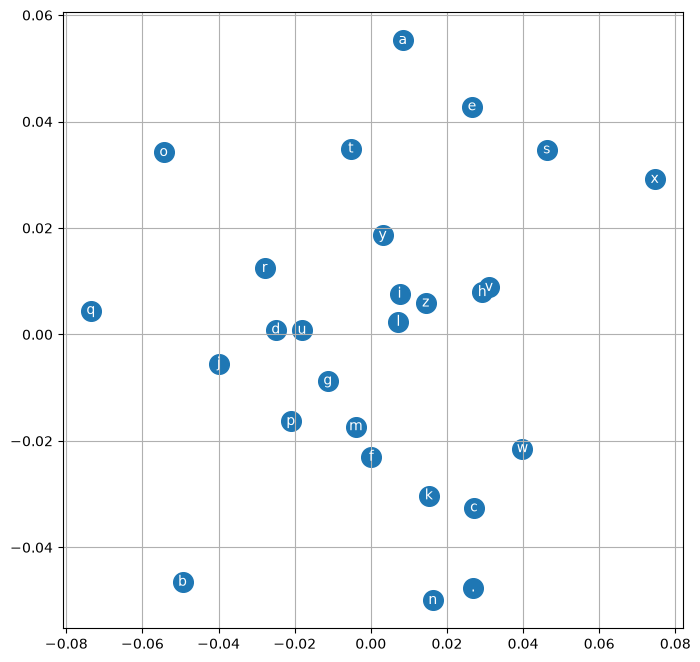

In [10]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [11]:

for _ in range(20):
    context = [0]*block_size
    out = []
    while True:
        hpreact = C[context].view(-1, n_embed_total) @ W1
        hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
        logits = torch.tanh(hpreact)@W2+b2
        probs = F.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        if not ix: break
        out += [itos[ix]]
    print("".join(out))


faron
marryah
elia
esio
dameei
aven
catonailin
denour
sarri
nailah
chanlenigija
sejteeiah
eyor
kaulleshan
erie
raychtreyleeel
naicella
ouslei
figh
rovese
